In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import matplotlib
import logging

# import utils as utils
from matplotlib import cm

In [2]:
runname = 'debug_withC_rogers_netcdfBdy1_EB_soliton_withsponge_focus_finey_summer'
datafilepath = '/Volumes/Tan_2024/SUNTANS/NLIW/iwave2024/dongsha/'+runname+'/data_f_1wave/'

# datafilename = 'sun_out.nc_0000.nc'
datafilename = 'sun_sparse.nc_0000.nc'

# path to saved result
resultfilepath = datafilepath+'/results/'
# path to saved figures
outfilepath = '../figure/'
if not os.path.exists(resultfilepath):
    os.mkdir(resultfilepath)
if not os.path.exists(outfilepath):
    os.mkdir(outfilepath)

param_data = {
    "datafilepath": datafilepath,
    "netcdf_filename": datafilename,
            }
param_result = {
    "resultfilepath": resultfilepath,
    "result_filename": 'sun_out_energy_derived.nc',
            }
idx_end = -15

# Read data

In [3]:
data = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_dissp.nc')
data_ = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'])

In [4]:
data_Cadv = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_Cadv.nc')

In [5]:
Cadv_int = data_Cadv.Ah0.integrate("time",datetime_unit="s")

In [33]:
# spatially filter dissipation; running mean, binsize = N
N = 50
Cadv_int_filter = Cadv_int.data.copy()
for i in range(len(data.x)):
    Cadv_int_filter[i,:] = np.convolve(Cadv_int_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    Cadv_int_filter[:,j] = np.convolve(Cadv_int_filter[:,j], np.ones(N)/N, 'same')

# Island center & Shoaling depth

In [34]:
lambdaM2=70.1e3
l_sponge = 20e3
L=1.5*lambdaM2+2*l_sponge
W=1.5*lambdaM2

x_c = 2*l_sponge+1.5*lambdaM2/2 
y_c = W/2

In [35]:
depth_top = 4
depth_shoal = 180
depth_bottom = 600-1e-2

# Section domain into circles & quadrants

In [36]:
data_c = xr.open_dataset('../results_intermediate/dis_theta_c.nc')
dis_c = data_c.dis_c.data
theta_c = data_c.theta_c.data

In [37]:
dis_top = np.mean(dis_c[np.where((data_.depth>=depth_top+.1) & (data_.depth.data<=depth_top+2))])
dis_shoal = np.mean(dis_c[np.where((data_.depth>=depth_shoal-1) & (data_.depth.data<=depth_shoal+1))])
dis_bottom = np.mean(dis_c[np.where((data_.depth>=depth_bottom-1) & (data_.depth.data<depth_bottom))])
quadrants_info = {
    "r_quad": np.array([dis_top, dis_shoal,dis_bottom]),
    "quadrants": ['east', 'north', 'west', 'south'],
    "theta_edge":np.array([-45, 45, 135, -135]),
    "theta_quad": [[-45, 45], [45, 135], [135, -135], [-135, -45]]
            }

In [38]:
# mask out data outside of the inner ring
mask_ring_inner = (dis_c>=quadrants_info["r_quad"][0]) & (dis_c<quadrants_info["r_quad"][1])
mask_ring_inner_east = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_inner_north = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_inner_west = mask_ring_inner & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_inner_south = mask_ring_inner & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# mask out data outside of the outer ring
mask_ring_outer = (dis_c>=quadrants_info["r_quad"][1]) & (dis_c<quadrants_info["r_quad"][-1])
mask_ring_outer_east = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][0][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][0][1]*np.pi/180)
mask_ring_outer_north = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][1][1]*np.pi/180)
mask_ring_outer_west = mask_ring_outer & ((theta_c>=quadrants_info["theta_quad"][2][0]*np.pi/180) | (theta_c<quadrants_info["theta_quad"][2][1]*np.pi/180))
mask_ring_outer_south = mask_ring_outer & (theta_c>=quadrants_info["theta_quad"][-1][0]*np.pi/180) & (theta_c<quadrants_info["theta_quad"][-1][1]*np.pi/180)

# Energy terms

## conversion

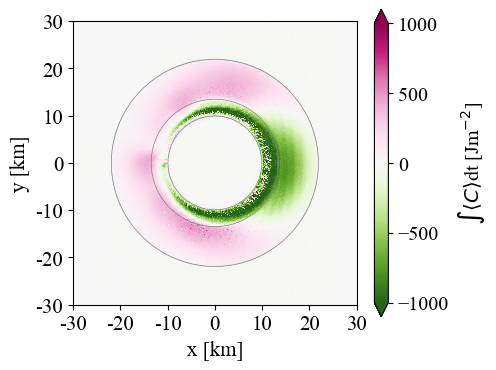

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))
im1 = (data_.C_int[-1,:,:]+Cadv_int_filter).T.plot.pcolormesh(ax=ax, vmax=1e3, vmin=-1e3, cmap=cm.PiYG_r, add_colorbar=False)
cb1 = plt.colorbar(im1, location='right', extend='both')
cb1.set_label(label=r"$\int\langle C\rangle$dt [Jm$^{-2}$]", size='x-large')
cb1.ax.tick_params(labelsize='x-large')
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)

ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_yticklabels(['-30','-20', '-10', '0', '10', '20','30'])
ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=15)
ax.set_ylabel('y [km]', fontsize=15)
ax.set_title(f'')
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
plt.tight_layout()

# plt.savefig(outfilepath+ f"C_overhead_summer_f.jpeg", dpi=300)

## energy flux

In [41]:
# https://stackoverflow.com/questions/5328128/scipy-interpolation-of-large-matrix

def interp2d_nearest(X, Y, Z, x, y, spn=3, method='linear'):
    from scipy import interpolate
    xs,ys = map(np.array,(x,y))
    z = np.zeros(xs.shape)
    for i,(x,y) in enumerate(zip(xs,ys)):
        # get the indices of the nearest x,y
        xi = np.argmin(np.abs(X[0,:]-x))
        yi = np.argmin(np.abs(Y[:,0]-y))
        xlo = max(xi-spn, 0)
        ylo = max(yi-spn, 0)
        xhi = min(xi+spn, X[0,:].size)
        yhi = min(yi+spn, Y[:,0].size)
        # make slices of X,Y,Z that are only a few items wide
        nX = X.T[xlo:xhi, ylo:yhi]
        nY = Y.T[xlo:xhi, ylo:yhi]
        nZ = Z[xlo:xhi, ylo:yhi]
        intp = interpolate.interp2d(nX, nY, nZ, method)
        z[i] = intp(x,y)[0]
    return z


In [42]:
data_bc_fx = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_x.nc')
data_bc_fy = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bc_flux_y.nc')

Fx_prime_int = data_bc_fx.Fx_prime1_int[-1,:,:].data+data_bc_fx.Fx_prime2_int[-1,:,:].data+data_bc_fx.Fx_prime3_int[-1,:,:].data+data_bc_fx.Fx_prime4_int[-1,:,:].data+data_bc_fx.Fx_prime5_int[-1,:,:].data
Fy_prime_int = data_bc_fy.Fy_prime1_int[-1,:,:].data+data_bc_fy.Fy_prime2_int[-1,:,:].data+data_bc_fy.Fy_prime3_int[-1,:,:].data+data_bc_fy.Fy_prime4_int[-1,:,:].data+data_bc_fy.Fy_prime5_int[-1,:,:].data
del data_bc_fx, data_bc_fy

In [43]:
data_bt_fx = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_x.nc')
data_bt_fy = xr.open_dataset(param_result['resultfilepath']+param_result['result_filename'][:-3]+'_bt_flux_y.nc')

Fx_0_int = data_bt_fx.Fx_01_int[-1,:,:].data+data_bt_fx.Fx_02_int[-1,:,:].data+data_bt_fx.Fx_03_int[-1,:,:].data+data_bt_fx.Fx_04_int[-1,:,:].data
Fy_0_int = data_bt_fy.Fy_01_int[-1,:,:].data+data_bt_fy.Fy_02_int[-1,:,:].data+data_bt_fy.Fy_03_int[-1,:,:].data+data_bt_fy.Fy_04_int[-1,:,:].data
del data_bt_fx, data_bt_fy

In [44]:
[xv, yv] = np.meshgrid(data.x.data,data.y.data)
# del data, data_

## transform to cylindrical coordinates

In [45]:
def cart_to_cyl(u,v,theta):
    """ this function transforms a cartesian vector u,v to cylindrical coordinates u_r, u_theta, with angle theta (rad)
    """
    u_r = u * np.cos(theta) + v * np.sin(theta)
    u_theta = -u * np.sin(theta) + v * np.cos(theta)
    return u_r, u_theta

In [46]:
F_prime_int_r, F_prime_int_theta = cart_to_cyl(Fx_prime_int, Fy_prime_int, theta_c)
F_0_int_r, F_0_int_theta = cart_to_cyl(Fx_0_int, Fy_0_int, theta_c)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/3711603698.py:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, F_prime_int_r.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)


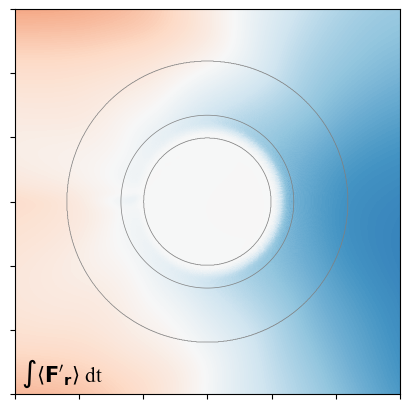

In [47]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
im1 = ax.pcolormesh(data.x.data, data.y.data, F_prime_int_r.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
# ax.set_xticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
ax.set_xticklabels('')
ax.set_yticklabels('')

ax.set_aspect('equal')
# ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title(r"$\int\langle\mathbf{F'_r}\rangle$ dt", fontsize=15)
ax.text(x_c-29000, y_c-28000, r"$\int\langle\mathbf{F'_r}\rangle$ dt", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

# plt.savefig(outfilepath+ f"Fprime_r_int_summer_f.png", transparent = True, dpi=300)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/1263778335.py:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, F_prime_int_theta.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)


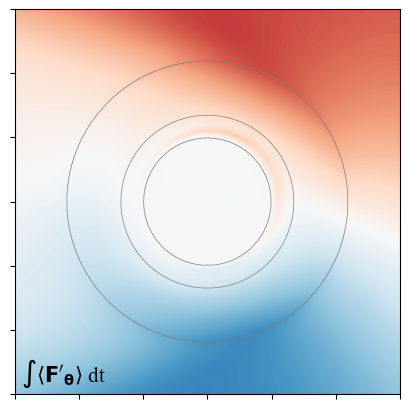

In [48]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
im1 = ax.pcolormesh(data.x.data, data.y.data, F_prime_int_theta.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
# ax.set_xticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
ax.set_xticklabels('')
ax.set_yticklabels('')

ax.set_aspect('equal')
# ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title(r"$\int\langle\mathbf{F'_r}\rangle$ dt", fontsize=15)
ax.text(x_c-29000, y_c-28000, r"$\int\langle\mathbf{F'_\theta}\rangle$ dt", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

# plt.savefig(outfilepath+ f"Fprime_theta_int_summer_f.png", transparent = True, dpi=300)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/970829627.py:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, F_0_int_r.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)


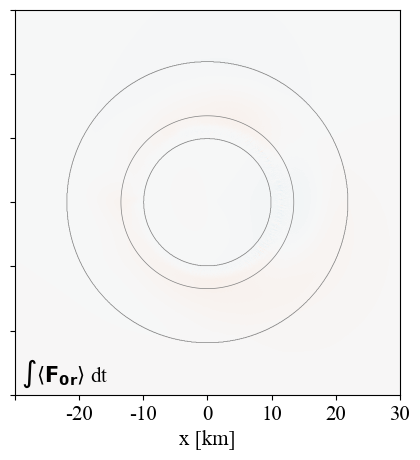

In [49]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
im1 = ax.pcolormesh(data.x.data, data.y.data, F_0_int_r.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', ''])
# ax.set_xticklabels('')
ax.set_yticklabels('')

ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
# ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title(r"$\int\langle\mathbf{F'_r}\rangle$ dt", fontsize=15)
ax.text(x_c-29000, y_c-28000, r"$\int\langle\mathbf{F_{0r}}\rangle$ dt", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

# plt.savefig(outfilepath+ f"F0_r_int_summer_f.png", transparent = True, dpi=300)

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/688196820.py:2: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, F_0_int_theta.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)


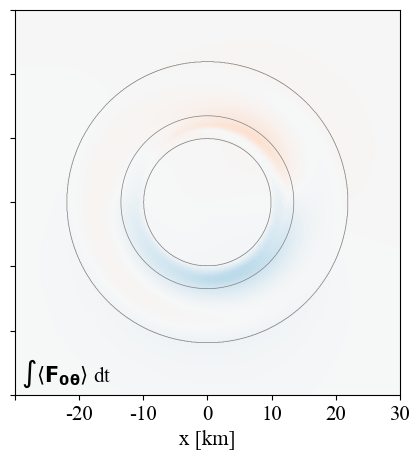

In [50]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
im1 = ax.pcolormesh(data.x.data, data.y.data, F_0_int_theta.T, vmax=50e6, vmin=-50e6, cmap=cm.RdBu_r)
ax.contour(data.x.data, data.y.data, data_.depth.data.T, levels = [depth_top, depth_shoal, depth_bottom], colors='0.5', linewidths=.5)
ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
ax.set_xticklabels(['', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
# ax.set_xticklabels('')
ax.set_yticklabels('')

ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
# ax.set_xlabel('')
ax.set_ylabel('')
# ax.set_title(r"$\int\langle\mathbf{F'_r}\rangle$ dt", fontsize=15)
ax.text(x_c-29000, y_c-28000, r"$\int\langle\mathbf{F_{0\theta}}\rangle$ dt", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

# plt.savefig(outfilepath+ f"F0_theta_int_summer_f.png", transparent = True, dpi=300)

## interp F onto rings and quadrants

/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=7,10 m=36 fp=1206761029.438494 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=8,9 m=36 fp=0.000000 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceed

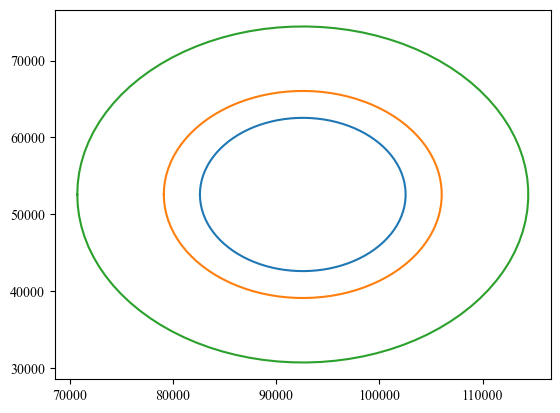

In [51]:
# interp F_prime onto rings and quadrants
x_circles = np.zeros((100, len(quadrants_info["r_quad"])))
y_circles = np.zeros((100, len(quadrants_info["r_quad"])))
Fx_prime_int_ring = np.zeros((100, len(quadrants_info["r_quad"])))
Fy_prime_int_ring = np.zeros((100, len(quadrants_info["r_quad"])))
Fx_0_int_ring = np.zeros((100, len(quadrants_info["r_quad"])))
Fy_0_int_ring = np.zeros((100, len(quadrants_info["r_quad"])))
# circles - small to big
theta_circles = np.linspace(-np.pi,np.pi,100)
for i in range(len(quadrants_info["r_quad"])):
    x_circles[:,i] = quadrants_info["r_quad"][i]*np.cos(theta_circles) + x_c
    y_circles[:,i] = quadrants_info["r_quad"][i]*np.sin(theta_circles) + y_c
    plt.plot(x_circles[:,i],y_circles[:,i])
    Fx_prime_int_ring[:,i] = interp2d_nearest(xv, yv, Fx_prime_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    Fy_prime_int_ring[:,i] = interp2d_nearest(xv, yv, Fy_prime_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    Fx_0_int_ring[:,i] = interp2d_nearest(xv, yv, Fx_0_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')
    Fy_0_int_ring[:,i] = interp2d_nearest(xv, yv, Fy_0_int, x_circles[:,i], y_circles[:,i], spn=3, method='linear')

/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=10,7 m=36 fp=24660426225.262550 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients already exceeds the number of data points m.
Probable causes: either s or m too small. (fp>s)
	kx,ky=1,1 nx,ny=7,10 m=36 fp=13890235777.584383 s=0.000000
  warnings.warn(RuntimeWarning(_iermess2[ierm][0] + _mess))
/Users/stan/miniforge3/envs/goship/lib/python3.9/site-packages/scipy/interpolate/_fitpack_impl.py:977: RuntimeWarning: No more knots can be added because the number of B-spline
coefficients al

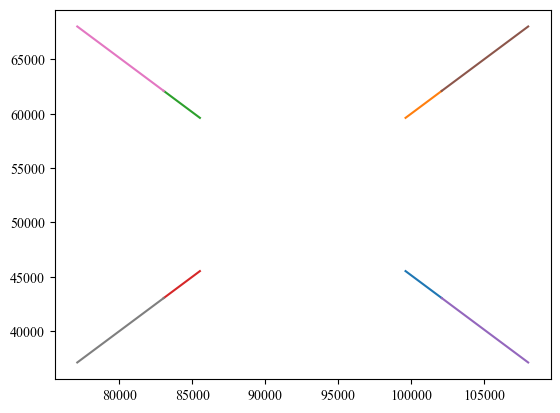

In [52]:
# interp F_prime onto rings and quadrants
x_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
y_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
Fx_prime_int_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
Fy_prime_int_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
Fx_0_int_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
Fy_0_int_edges = np.zeros((100, len(quadrants_info["quadrants"]), len(quadrants_info["r_quad"])-1))
# edges
for ii in range(len(quadrants_info["r_quad"])-1):
    r_edges = np.linspace(quadrants_info["r_quad"][ii],quadrants_info["r_quad"][ii+1],100)
    for i in range(len(quadrants_info["quadrants"])):
        x_edges[:,i,ii] = r_edges*np.cos(np.pi*quadrants_info["theta_edge"][i]/180) + x_c
        y_edges[:,i,ii] = r_edges*np.sin(np.pi*quadrants_info["theta_edge"][i]/180) + y_c
        plt.plot(x_edges[:,i,ii],y_edges[:,i,ii])
        Fx_prime_int_edges[:,i,ii] = interp2d_nearest(xv, yv, Fx_prime_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        Fy_prime_int_edges[:,i,ii] = interp2d_nearest(xv, yv, Fy_prime_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        Fx_0_int_edges[:,i,ii] = interp2d_nearest(xv, yv, Fx_0_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')
        Fy_0_int_edges[:,i,ii] = interp2d_nearest(xv, yv, Fy_0_int, x_edges[:,i,ii], y_edges[:,i,ii], spn=3, method='linear')

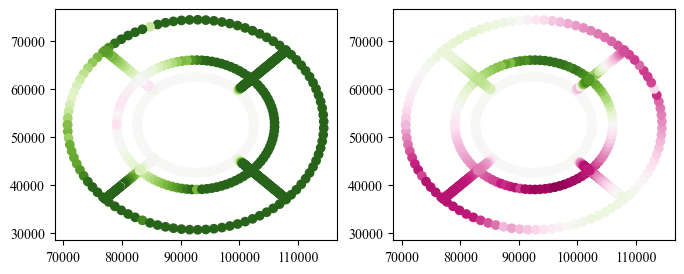

In [53]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

ax[0].scatter(x_circles, y_circles, c=Fx_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[0].scatter(x_edges, y_edges, c=Fx_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

ax[1].scatter(x_circles, y_circles, c=Fy_prime_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[1].scatter(x_edges, y_edges, c=Fy_prime_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

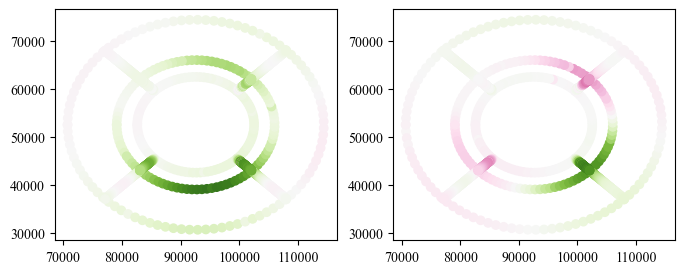

In [54]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(8,3))

ax[0].scatter(x_circles, y_circles, c=Fx_0_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[0].scatter(x_edges, y_edges, c=Fx_0_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

ax[1].scatter(x_circles, y_circles, c=Fy_0_int_ring, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)
ax[1].scatter(x_edges, y_edges, c=Fy_0_int_edges, vmin=-1e7,vmax=1e7, cmap=cm.PiYG_r)

In [55]:
dissip0 = data.dissip0[-1,:,:]-Cadv_int
dissip_prime = data.dissip_prime[-1,:,:]+Cadv_int

# spatially filter dissipation; running mean, binsize = N
N = 10
dissip_prime_filter = dissip_prime.data.copy()
dissip_0_filter = dissip0.data.copy()
for i in range(len(data.x)):
    dissip_prime_filter[i,:] = np.convolve(dissip_prime_filter[i,:], np.ones(N)/N, 'same')
    dissip_0_filter[i,:] = np.convolve(dissip_0_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    dissip_prime_filter[:,j] = np.convolve(dissip_prime_filter[:,j], np.ones(N)/N, 'same')
    dissip_0_filter[:,j] = np.convolve(dissip_0_filter[:,j], np.ones(N)/N, 'same')

In [56]:
x_upstreams = [x_c+40e3, x_c+25e3]
x_downstreams = [x_c-40e3, x_c-25e3]

# Plot

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/433048907.py:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, (dissip_prime_filter+dissip_0_filter).T, vmax=1e4, vmin=0, cmap=cm.pink_r)


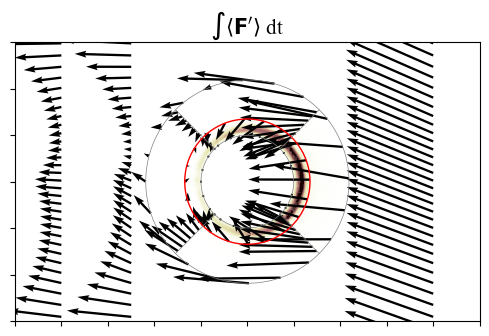

In [57]:
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,7))
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
# im1 = (data.dissip0[-1,:,:]+data.dissip_prime[-1,:,:]).T.plot(ax=ax, vmax=1e4, vmin=0, cmap=cm.Reds, add_colorbar=False)
im1 = ax.pcolormesh(data.x.data, data.y.data, (dissip_prime_filter+dissip_0_filter).T, vmax=1e4, vmin=0, cmap=cm.pink_r)
# cb1 = plt.colorbar(im1, shrink=0.8, location='bottom', extend='max', ticks=np.arange(0,1e4+1,2e3))
# cb1.set_label(label=r"$\int(\langle\epsilon\rangle+D)dt$ [kJm$^{-2}$]", size='x-large')
# cb1.ax.set_xticklabels(['0','2','4','6','8','10'])
# cb1.ax.tick_params(labelsize='x-large')
ax.plot(x_circles[:,0],y_circles[:,0],c='grey',lw=.5)
ax.plot(x_circles[:,1],y_circles[:,1],c='r',lw=1)
ax.plot(x_circles[:,-1],y_circles[:,-1],c='grey',lw=.5)
idx_x = 1020
# ax.plot([data.x[idx_x],data.x[idx_x]],[data.y[0],data.y[-1]],'k',ls='--')
# ax.plot(data.x.data[idx_x], y_c-30000+500,'k^',markersize=10)
# ax.plot(data.x.data[idx_x], y_c+30000-500,'kv',markersize=10)
for ii in range(len(quadrants_info["r_quad"])-1):
    ax.plot(x_edges[:,:,ii],y_edges[:,:,ii],c='grey',lw=.5)
Q = ax.quiver(x_circles[::5,:], y_circles[::5,:], Fx_prime_int_ring[::5,:], Fy_prime_int_ring[::5,:], scale=.4e+8, scale_units='inches', width=5e-3)
ax.quiver(x_edges[::25,:,0], y_edges[::25,:,0], Fx_prime_int_edges[::25,:,0], Fy_prime_int_edges[::25,:,0], scale=.4e+8, scale_units='inches', width=5e-3)
ax.quiver(x_edges[::15,:,1], y_edges[::15,:,1], Fx_prime_int_edges[::15,:,1], Fy_prime_int_edges[::15,:,1], scale=.4e+8, scale_units='inches', width=5e-3)
# ax.quiver(x_c-5000, y_c-29000, .2e+8, 0, color='k', scale=.4e+8, scale_units='inches', width=5e-3)
# ax.text(x_c-5000, y_c-29000+1500,r'20 MJm$^{-1}$',color='k', fontsize=12)
# qk = ax.quiverkey(Q, 0.1, 1.03, .2e+8, r'20 MJm$^{-1}$', labelpos='E', fontproperties={'size':14})

# ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
# ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
# ax.set_xticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
ax.set_yticklabels('')
x_upstream = x_upstreams[0]
ax.quiver(data.x.sel(x=x_upstream, method='nearest').data*np.ones(data.y.data[::30].shape), data.y.data[::30], Fx_prime_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], Fy_prime_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], scale=.4e+8, scale_units='inches', width=5e-3)
# for x_upstream in x_upstreams:
#     ax.quiver(data.x.sel(x=x_upstream, method='nearest').data*np.ones(data.y.data[::30].shape), data.y.data[::30], Fx_prime_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], Fy_prime_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], scale=.4e+8, scale_units='inches', width=5e-3)
for x_downstream in x_downstreams:
    ax.quiver(data.x.sel(x=x_downstream, method='nearest').data*np.ones(data.y.data[::30].shape), data.y.data[::30], Fx_prime_int[np.where(data.x.data == data.x.sel(x=x_downstream, method='nearest').data)[0][0], ::30], Fy_prime_int[np.where(data.x.data == data.x.sel(x=x_downstream, method='nearest').data)[0][0], ::30], scale=.4e+8, scale_units='inches', width=5e-3)
ax.set_xlim([x_c-50000, x_c+50000])
# ax.set_ylim([y_c-50000, y_c+50000])
ax.set_xticks(np.arange(x_c-50000,x_c+50000+1,10000))
# ax.set_yticks(np.arange(y_c-50000,y_c+50000+1,10000))
ax.set_xticklabels('')
# ax.set_xticklabels(['-50','-40', '-30','-20', '-10', '0', '10', '20','30', '40','50'])
# ax.set_yticklabels(['-50','-40', '-30','-20', '-10', '0', '10', '20','30', '40','50'])

ax.set_aspect('equal')
# ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
ax.set_title(r"$\int\langle\mathbf{F'}\rangle$ dt", fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

plt.savefig(outfilepath+ f"Fprime_dissp_int_summer_f.png", transparent = True, dpi=300)

In [58]:
C_int = data_.C_int

# spatially filter dissipation; running mean, binsize = N
N = 10
C_int_filter = C_int[-1,:,:].data.copy()
for i in range(len(data.x)):
    C_int_filter[i,:] = np.convolve(C_int_filter[i,:], np.ones(N)/N, 'same')
for j in range(len(data.y)):
    C_int_filter[:,j] = np.convolve(C_int_filter[:,j], np.ones(N)/N, 'same')

/var/folders/sr/6_bkfhj929364hv72k5pf2jw0000gn/T/ipykernel_71058/3270076753.py:4: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  im1 = ax.pcolormesh(data.x.data, data.y.data, (C_int_filter+Cadv_int_filter).T, vmax=1e3, vmin=-1e3, cmap=cm.PiYG_r)


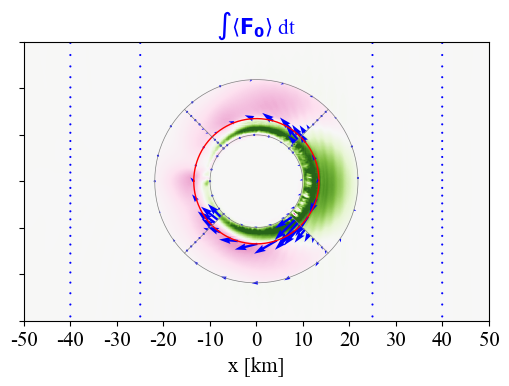

In [59]:
# fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,7))
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))
# im1 = data_.C_int[-1,:,:].T.plot(ax=ax, vmax=1e3, vmin=-1e3, cmap=cm.PiYG_r, add_colorbar=False)
im1 = ax.pcolormesh(data.x.data, data.y.data, (C_int_filter+Cadv_int_filter).T, vmax=1e3, vmin=-1e3, cmap=cm.PiYG_r)
# cb1 = plt.colorbar(im1, shrink=0.8, location='bottom', extend='both', ticks=np.arange(-1e3,1e3+1,5e2))
# cb1.set_label(label=r"$\int\langle C\rangle$dt [kJm$^{-2}$]", size='x-large')
# cb1.ax.set_xticklabels(['-1','-0.5','0','0.5','1'])
# cb1.ax.tick_params(labelsize='x-large')
ax.plot(x_circles[:,0],y_circles[:,0],c='grey',lw=.5)
ax.plot(x_circles[:,1],y_circles[:,1],c='r',lw=1)
ax.plot(x_circles[:,-1],y_circles[:,-1],c='grey',lw=.5)
idx_x = 1020
# ax.plot([data.x[idx_x],data.x[idx_x]],[data.y[0],data.y[-1]],'k',ls='--')
# ax.plot(data.x.data[idx_x], y_c-30000+500,'k^',markersize=10)
# ax.plot(data.x.data[idx_x], y_c+30000-500,'kv',markersize=10)
for ii in range(len(quadrants_info["r_quad"])-1):
    ax.plot(x_edges[:,:,ii],y_edges[:,:,ii],c='grey',lw=.5)
Q = ax.quiver(x_circles[::5,:], y_circles[::5,:], Fx_0_int_ring[::5,:], Fy_0_int_ring[::5,:], scale=.4e+8, scale_units='inches', width=5e-3, color='b')
ax.quiver(x_edges[::25,:,0], y_edges[::25,:,0], Fx_0_int_edges[::25,:,0], Fy_0_int_edges[::25,:,0], scale=.4e+8, scale_units='inches', width=5e-3, color='b')
ax.quiver(x_edges[::15,:,1], y_edges[::15,:,1], Fx_0_int_edges[::15,:,1], Fy_0_int_edges[::15,:,1], scale=.4e+8, scale_units='inches', width=5e-3, color='b')
# qk = ax.quiverkey(Q, 0.1, 1.03, .2e+8, r'20 MJm$^{-1}$', labelpos='E', fontproperties={'size':14}, labelcolor='b')
# ax.quiver(x_c-30000+1000, y_c-30000+1000, .2e+8, 0, color='b', scale=.4e+8, scale_units='inches', width=5e-3)
# ax.text(x_c-30000+1000, y_c-30000+1500,r'20 MJm$^{-1}$',color='b', fontsize=12)
# ax.set_xlim([x_c-30000, x_c+30000])
ax.set_ylim([y_c-30000, y_c+30000])
# ax.set_xticks(np.arange(x_c-30000,x_c+30000+1,10000))
ax.set_yticks(np.arange(y_c-30000,y_c+30000+1,10000))
# ax.set_xticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
# ax.set_yticklabels(['-30', '-20', '-10', '0', '10', '20', '30'])
ax.set_yticklabels('')
for x_upstream in x_upstreams:
    ax.quiver(data.x.sel(x=x_upstream, method='nearest').data*np.ones(data.y.data[::30].shape), data.y.data[::30], Fx_0_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], Fy_0_int[np.where(data.x.data == data.x.sel(x=x_upstream, method='nearest').data)[0][0], ::30], scale=.4e+8, scale_units='inches', width=5e-3, color='b')
for x_downstream in x_downstreams: 
    ax.quiver(data.x.sel(x=x_downstream, method='nearest').data*np.ones(data.y.data[::30].shape), data.y.data[::30], Fx_0_int[np.where(data.x.data == data.x.sel(x=x_downstream, method='nearest').data)[0][0], ::30], Fy_0_int[np.where(data.x.data == data.x.sel(x=x_downstream, method='nearest').data)[0][0], ::30], scale=.4e+8, scale_units='inches', width=5e-3, color='b')
ax.set_xlim([x_c-50000, x_c+50000])
# ax.set_ylim([y_c-50000, y_c+50000])
ax.set_xticks(np.arange(x_c-50000,x_c+50000+1,10000))
# ax.set_yticks(np.arange(y_c-50000,y_c+50000+1,10000))
ax.set_xticklabels(['-50','-40', '-30','-20', '-10', '0', '10', '20','30', '40','50'])
# ax.set_yticklabels(['-50','-40', '-30','-20', '-10', '0', '10', '20','30', '40','50'])
ax.set_aspect('equal')
ax.set_xlabel('x [km]', fontsize=15)
# ax.set_ylabel('y [km]', fontsize=15)
ax.set_title(r"$\int\langle\mathbf{F_0}\rangle$ dt", fontsize=15, color='b')
ax.tick_params(axis='both', which='major', labelsize=15)
plt.rcParams["font.family"] = "Times New Roman"
# plt.tight_layout()

plt.savefig(outfilepath+ f"F0_C_int_summer_f.png", transparent = True, dpi=300)